# Input Generation — PV Generation Profile Kassel 10 kWp (2019 weather → 2026-aligned, 15-min)

## Purpose

This notebook generates the **15-minute rooftop PV power and energy time series** used as the exogenous solar generation signal in all archetype–DSO runs that include a PV system.

**Raw input file:** `raw-data/renewablesninja_pv_kassel_10kWp_merra2_2019_retrieved_2026-02.csv`  
**Output file:** `inputs/pv_kassel_10kwp_2026_15min.csv`

## Data source

PV generation is sourced from *renewables.ninja*:

> Renewables.ninja. (n.d.). *Renewables.ninja*. Retrieved February 2026, from https://www.renewables.ninja/
>
> Pfenninger, S., & Staffell, I. (2016). Long-term patterns of European PV output using 30 years of validated hourly reanalysis and satellite data. *Energy, 114*, 1251–1265. https://doi.org/10.1016/j.energy.2016.08.060

## System configuration

| Parameter | Value |
|---|---|
| Location | Kassel, Germany (51.31°N, 9.50°E) |
| Installed capacity | 10 kWp |
| Orientation | South-facing, azimuth 180° |
| Tilt | 35° |
| System loss | 10% |
| Weather dataset | MERRA-2 global reanalysis |
| Reference year | 2019 |
| Output unit | kW (hourly) |

Kassel is selected as a representative central German location. The 2019 weather year serves as a clean proxy meteorological year; the PV profile is used as an exogenous generation pattern rather than a calendar-aligned behavioural series, so a single representative year is sufficient.

## Processing steps

1. Load the hourly CSV export (8,760 hourly values).
2. Expand each hourly value to four identical 15-minute slots (piecewise-constant 1h → 4×15min), yielding 35,040 quarter-hours.
3. Assign a 2026 calendar index (`2026-01-01 00:00` → `2026-12-31 23:45`) so that the PV series shares the same temporal index as all other input files.
4. Derive per-slot energy: `energy_kWh = power_kW × 0.25 h`.

## Thesis reference

Chapter 3, Section 3.5.2 — *PV Profile (Kassel 10 kWp)*

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT  = find_repo_root()
RAW_DATA   = REPO_ROOT / 'data' / 'raw'
INPUTS     = REPO_ROOT / 'inputs'
INPUTS.mkdir(parents=True, exist_ok=True)

RAW_PATH   = RAW_DATA / 'renewablesninja_pv_kassel_10kWp_merra2_2019_retrieved_2026-02.csv'
OUTPUT_CSV = INPUTS   / 'pv_kassel_10kwp_2026_15min.csv'

assert RAW_PATH.exists(), f'Raw file not found: {RAW_PATH}'
print(f'Raw source : {RAW_PATH.name}')
print(f'Output     : {OUTPUT_CSV}')

Raw source : renewablesninja_pv_kassel_10kWp_merra2_2019_retrieved_2026-02.csv
Output     : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/pv_kassel_10kwp_2026_15min.csv


## Step 1 — Load hourly PV data

In [7]:
# Lines beginning with '#' are metadata comments from the renewables.ninja export;
# comment='#' skips them and reads the CSV header on the first non-comment line.
df_raw = pd.read_csv(RAW_PATH, comment='#')
df_raw['local_time'] = pd.to_datetime(df_raw['local_time'])
df_raw = df_raw.set_index('local_time').sort_index()

p_kw = df_raw['electricity']   # hourly power in kW

print(f'Hours loaded  : {len(p_kw):,}')
print(f'Date range    : {p_kw.index.min()}  ->  {p_kw.index.max()}')
print(f'Annual output : {p_kw.sum():.1f} kWh')
print(f'Peak power    : {p_kw.max():.3f} kW')
print(f'Hours with generation > 0 : {(p_kw > 0).sum():,}')

Hours loaded  : 8,760
Date range    : 2019-01-01 01:00:00  ->  2020-01-01 00:00:00
Annual output : 11749.3 kWh
Peak power    : 8.026 kW
Hours with generation > 0 : 4,126


## Step 2 — Expand to 15-min resolution and assign 2026 calendar index

In [3]:
# Each hourly kW value is repeated four times for the four 15-minute slots of that hour
# (piecewise-constant expansion; power is time-invariant within each hour).
# The index is reassigned to 2026 so that the PV series aligns with all other inputs.
idx_2026 = pd.date_range('2026-01-01 00:00', periods=len(p_kw) * 4, freq='15min')
pv_15min = pd.Series(np.repeat(p_kw.values, 4), index=idx_2026, name='power_kW')

print(f'15-min slots  : {len(pv_15min):,}')
print(f'Date range    : {pv_15min.index[0]}  ->  {pv_15min.index[-1]}')
print(f'Annual output : {pv_15min.sum() * 0.25:.1f} kWh  (consistent with hourly: {p_kw.sum():.1f} kWh)')

15-min slots  : 35,040
Date range    : 2026-01-01 00:00:00  ->  2026-12-31 23:45:00
Annual output : 11749.3 kWh  (consistent with hourly: 11749.3 kWh)


## Step 3 — Visualisation

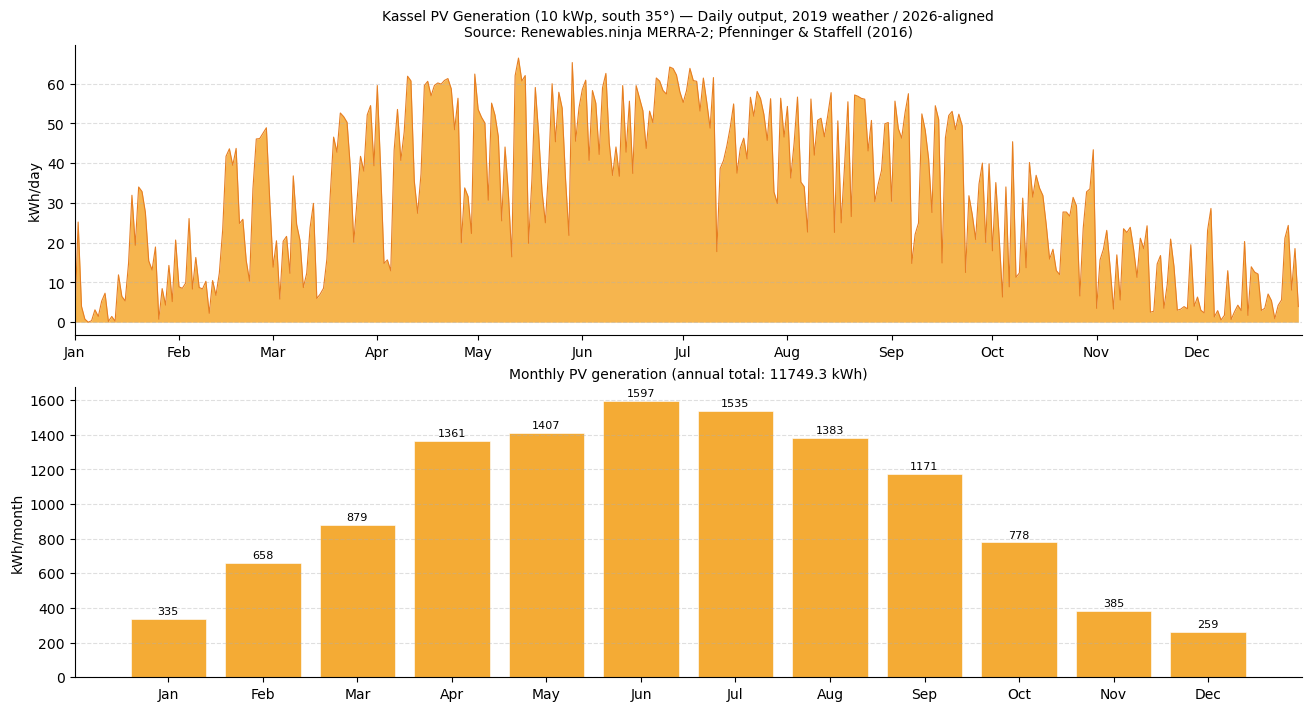

In [4]:
daily_kwh   = pv_15min.resample('D').sum() * 0.25
monthly_kwh = pv_15min.resample('MS').sum() * 0.25

fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)

# Upper panel: daily PV generation over the full year
axes[0].fill_between(daily_kwh.index, daily_kwh.values, 0,
                     color='#f39c12', alpha=0.75, linewidth=0)
axes[0].plot(daily_kwh.index, daily_kwh.values, lw=0.8, color='#e67e22')
axes[0].set_ylabel('kWh/day')
axes[0].set_title(
    'Kassel PV Generation (10 kWp, south 35°) — Daily output, 2019 weather / 2026-aligned\n'
    'Source: Renewables.ninja MERRA-2; Pfenninger & Staffell (2016)',
    fontsize=10
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].set_xlim(pv_15min.index[0], pv_15min.index[-1])
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Lower panel: monthly bar chart
month_labels = monthly_kwh.index.strftime('%b')
bars = axes[1].bar(range(12), monthly_kwh.values, color='#f39c12', alpha=0.85,
                   edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_labels)
axes[1].set_ylabel('kWh/month')
axes[1].set_title(f'Monthly PV generation (annual total: {monthly_kwh.sum():.1f} kWh)', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

# Annotate each bar with its value
for bar, val in zip(bars, monthly_kwh.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 15,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

## Step 4 — Summary statistics

In [5]:
annual_kwh  = pv_15min.sum() * 0.25
peak_kw     = pv_15min.max()
slots_pos   = (pv_15min > 0).sum()
cf          = annual_kwh / (10 * 8760)   # capacity factor = annual kWh / (kWp * hours/year)

print('Kassel PV Generation — Summary')
print('-' * 45)
print(f'  System capacity         : 10.0 kWp')
print(f'  Annual output           : {annual_kwh:.1f} kWh')
print(f'  Specific yield          : {annual_kwh/10:.1f} kWh/kWp')
print(f'  Peak 15-min power       : {peak_kw:.3f} kW')
print(f'  Capacity factor         : {cf:.3f}')
print(f'  Slots with generation   : {slots_pos:,} of {len(pv_15min):,}')
print('-' * 45)

Kassel PV Generation — Summary
---------------------------------------------
  System capacity         : 10.0 kWp
  Annual output           : 11749.3 kWh
  Specific yield          : 1174.9 kWh/kWp
  Peak 15-min power       : 8.026 kW
  Capacity factor         : 0.134
  Slots with generation   : 16,504 of 35,040
---------------------------------------------


## Step 5 — Export to CSV

In [8]:
df_out = pd.DataFrame({
    'datetime'   : pv_15min.index.strftime('%Y-%m-%d %H:%M'),
    'power_kW'   : pv_15min.values.round(6),
    'energy_kWh' : (pv_15min.values * 0.25).round(6),   # kW × 0.25 h
})

df_out.to_csv(OUTPUT_CSV, index=False)

print(f'Exported : {OUTPUT_CSV}')
print(f'Shape    : {df_out.shape}')
print()
print(df_out.head(6).to_string(index=False))

Exported : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/pv_kassel_10kWp_2026_15min.csv
Shape    : (35040, 3)

        datetime  power_kW  energy_kWh
2026-01-01 00:00       0.0         0.0
2026-01-01 00:15       0.0         0.0
2026-01-01 00:30       0.0         0.0
2026-01-01 00:45       0.0         0.0
2026-01-01 01:00       0.0         0.0
2026-01-01 01:15       0.0         0.0
